# Gráficos

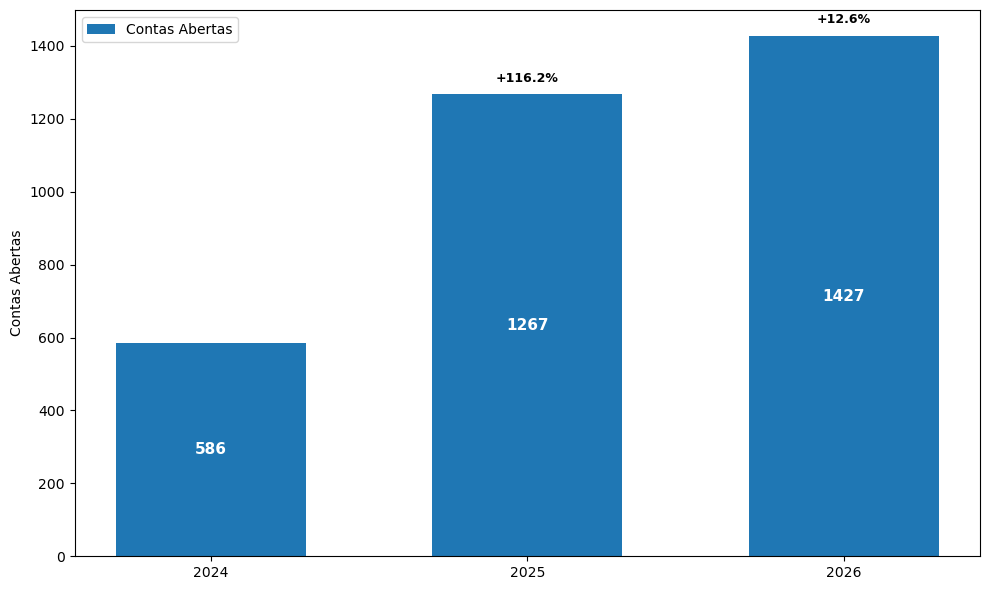

In [1]:
# Acumulado de contas abertas por ano, com crescimento YoY
import matplotlib.pyplot as plt
import numpy as np

# Dados
anos = ["2024", "2025", "2026"]
valores = [586, 1267, 1427]  # Valores acumulados por ano

# Crescimento YoY
delta_pct = [
    None,  # 2024 não tem comparação
    (valores[1] - valores[0]) / valores[0] * 100,
    (valores[2] - valores[1]) / valores[1] * 100
]

x = np.arange(len(anos))
width = 0.6

plt.figure(figsize=(10,6))

bars = plt.bar(x, valores, width, label="Contas Abertas")

# Valores dentro das barras
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h * 0.5,
        f"{int(h)}",
        ha="center", va="center",
        color="white",
        fontsize=11,
        fontweight="bold"
    )

# % YoY logo acima das barras
for i, pct in enumerate(delta_pct):
    if pct is not None:
        plt.text(
            i,
            valores[i] + valores[i]*0.02,  # 2% acima da barra
            f"{pct:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.xticks(x, anos)
plt.ylabel("Contas Abertas")
# plt.title("Evolução Anual – Contas Abertas")
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()


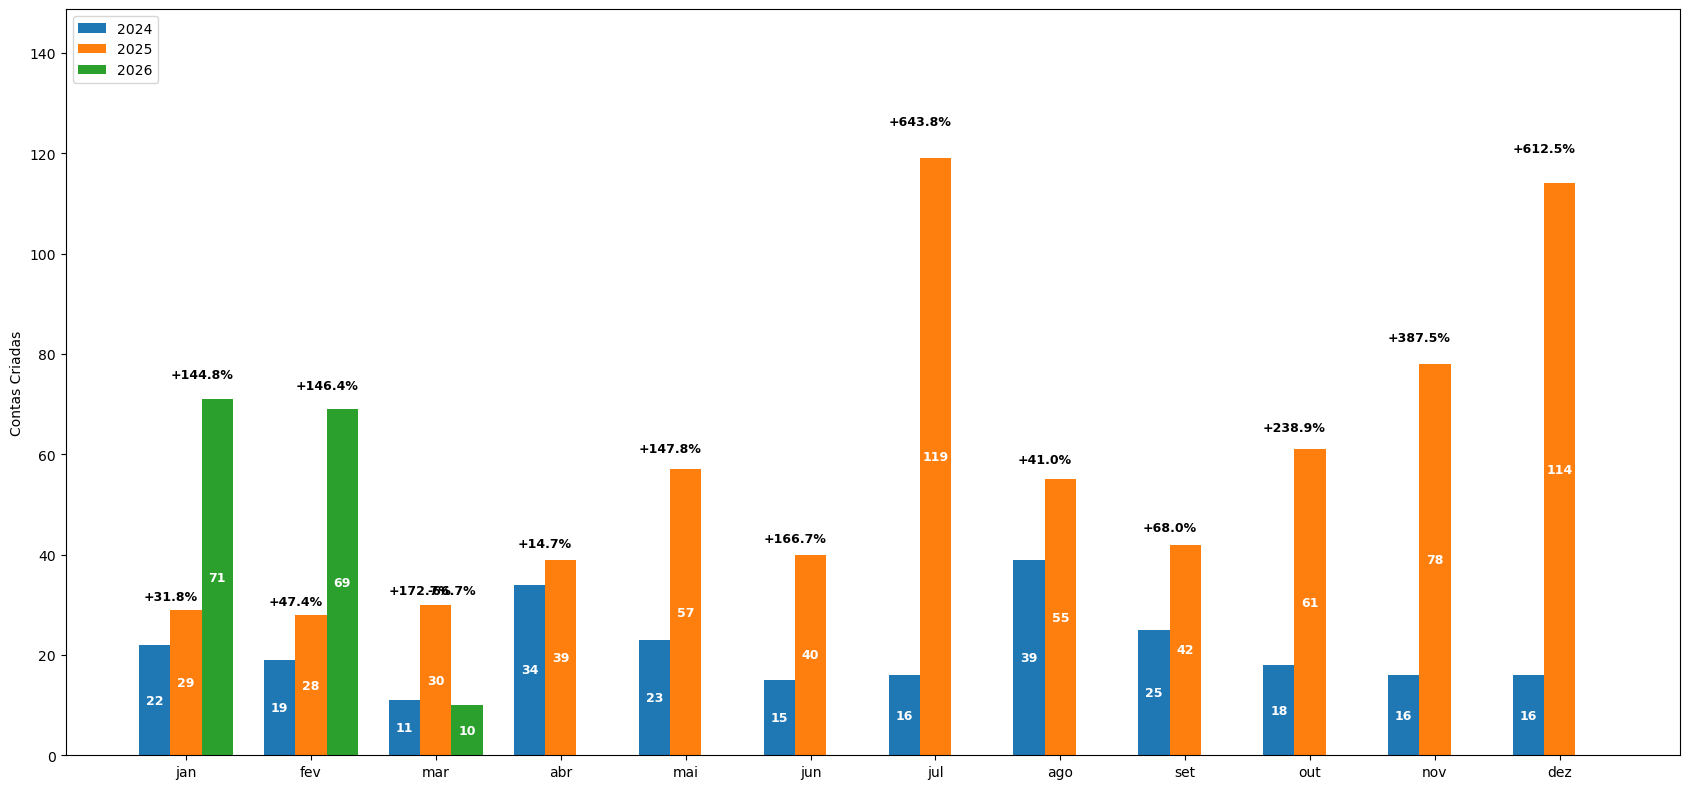

In [5]:
# Contas criadas mes a mes e YoY ano a ano

# Meses
meses = [
    "jan","fev","mar","abr","mai","jun",
    "jul","ago","set","out","nov","dez"
]

# Valores
val_2024 = [22, 19, 11, 34, 23, 15, 16, 39, 25, 18, 16, 16]
val_2025 = [29, 28, 30, 39, 57, 40, 119, 55, 42, 61, 78, 114]

# 2026 (resto zerado)
val_2026 = [71, 69, 10] + [0]*(12-3)

# YoY 2025 vs 2024
delta_25 = [
    (v25 - v24) / v24 * 100
    for v24, v25 in zip(val_2024, val_2025)
]

# YoY 2026 vs 2025
delta_26 = []
for v26, v25 in zip(val_2026, val_2025):
    if v26 != 0:
        delta_26.append((v26 - v25) / v25 * 100)
    else:
        delta_26.append(None)

x = np.arange(len(meses))
width = 0.25

plt.figure(figsize=(17,8))

bars_2024 = plt.bar(x - width, val_2024, width, label="2024")
bars_2025 = plt.bar(x, val_2025, width, label="2025")
bars_2026 = plt.bar(x + width, val_2026, width, label="2026")

# Valores dentro das barras
for bars in [bars_2024, bars_2025, bars_2026]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            plt.text(
                bar.get_x() + bar.get_width()/2,
                h * 0.5,
                f"{int(h)}",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold"
            )

# % YoY 2025
for i, pct in enumerate(delta_25):
    ymax = max(val_2024[i], val_2025[i])
    plt.text(
        i - width/2,
        ymax + ymax*0.05,
        f"{pct:+.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# % YoY 2026
for i, pct in enumerate(delta_26):
    if pct is not None:
        ymax = max(val_2025[i], val_2026[i])
        plt.text(
            i + width/2,
            ymax + ymax*0.05,
            f"{pct:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.xticks(x, meses)
plt.ylabel("Contas Criadas")

# Espaço extra no topo
max_val = max(val_2024 + val_2025 + val_2026)
plt.ylim(0, max_val * 1.25)

# legenda
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

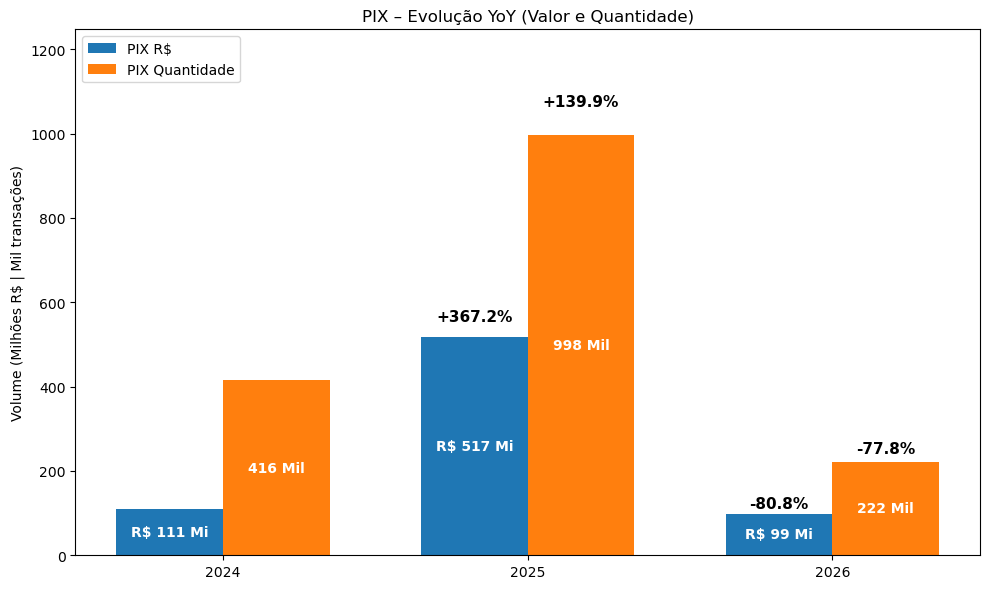

In [12]:
# Dados PIX

anos = ["2024", "2025", "2026"]

# Valores normalizados
pix_valor = [110.61, 516.75, 99]   # Milhões de reais
pix_qtd = [416, 998, 222]          # Mil transações

# Crescimento YoY
delta_valor = [
    None,
    (pix_valor[1] - pix_valor[0]) / pix_valor[0] * 100,
    (pix_valor[2] - pix_valor[1]) / pix_valor[1] * 100
]

delta_qtd = [
    None,
    (pix_qtd[1] - pix_qtd[0]) / pix_qtd[0] * 100,
    (pix_qtd[2] - pix_qtd[1]) / pix_qtd[1] * 100
]

x = np.arange(len(anos))
width = 0.35

plt.figure(figsize=(10,6))

# Barras
bars_valor = plt.bar(x - width/2, pix_valor, width, label="PIX R$")
bars_qtd = plt.bar(x + width/2, pix_qtd, width, label="PIX Quantidade")

# Valores dentro das barras
for bar in bars_valor:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h * 0.5,
        f"R$ {h:,.0f} Mi".replace(",", "."),
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

for bar in bars_qtd:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h * 0.5,
        f"{int(h)} Mil",
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold"
    )


# % YoY acima
for i in range(len(anos)):
    if delta_valor[i] is not None:
        plt.text(
            x[i] - width/2,
            pix_valor[i] * 1.06,
            f"{delta_valor[i]:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    if delta_qtd[i] is not None:
        plt.text(
            x[i] + width/2,
            pix_qtd[i] * 1.06,
            f"{delta_qtd[i]:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

# Ajustes finais
plt.xticks(x, anos)
plt.ylabel("Volume (Milhões R$ | Mil transações)")
plt.title("PIX – Evolução YoY (Valor e Quantidade)")

# margem para não cortar os %
max_val = max(pix_valor + pix_qtd)
plt.ylim(0, max_val * 1.25)

plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

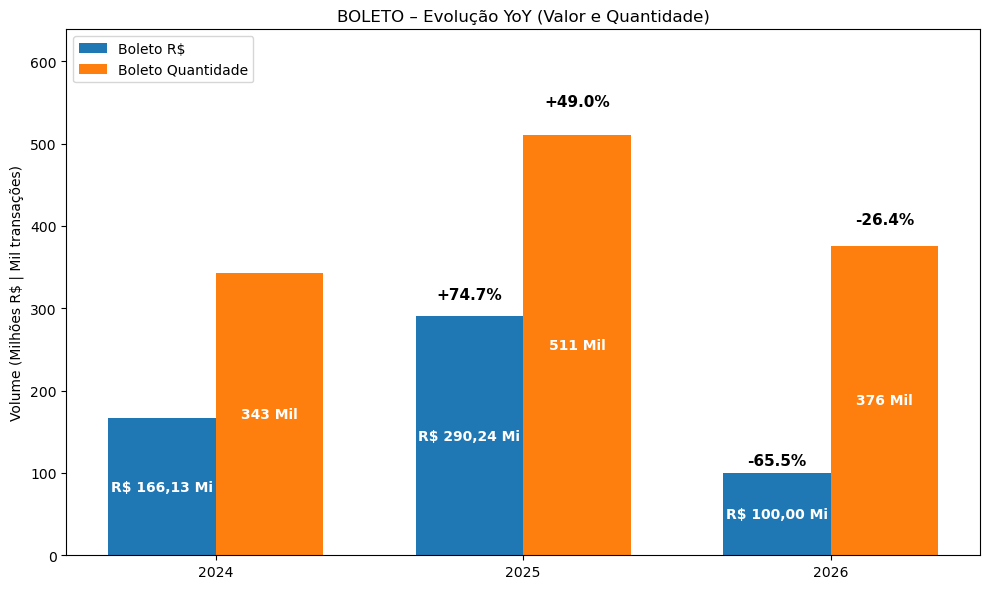

In [13]:
# Dados BOLETO
anos = ["2024", "2025", "2026"]

# Valores normalizados
boleto_valor = [166.13, 290.24, 100]   # Milhões de reais
boleto_qtd = [343, 511, 376]           # Mil transações

# Crescimento YoY
delta_valor = [
    None,
    (boleto_valor[1] - boleto_valor[0]) / boleto_valor[0] * 100,
    None if boleto_valor[2] == 0 else (boleto_valor[2] - boleto_valor[1]) / boleto_valor[1] * 100
]

delta_qtd = [
    None,
    (boleto_qtd[1] - boleto_qtd[0]) / boleto_qtd[0] * 100,
    None if boleto_qtd[2] == 0 else (boleto_qtd[2] - boleto_qtd[1]) / boleto_qtd[1] * 100
]

x = np.arange(len(anos))
width = 0.35

plt.figure(figsize=(10,6))

# Barras
bars_valor = plt.bar(x - width/2, boleto_valor, width, label="Boleto R$")
bars_qtd = plt.bar(x + width/2, boleto_qtd, width, label="Boleto Quantidade")

# Valores dentro das barras
for bar in bars_valor:
    h = bar.get_height()
    if h > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h * 0.5,
            f"R$ {h:,.2f} Mi".replace(",", "X").replace(".", ",").replace("X", "."),
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

for bar in bars_qtd:
    h = bar.get_height()
    if h > 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h * 0.5,
            f"{int(h)} Mil",
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )

# % YoY acima
for i in range(len(anos)):
    if delta_valor[i] is not None:
        plt.text(
            x[i] - width/2,
            boleto_valor[i] * 1.06,
            f"{delta_valor[i]:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    if delta_qtd[i] is not None:
        plt.text(
            x[i] + width/2,
            boleto_qtd[i] * 1.06,
            f"{delta_qtd[i]:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

# Ajustes finais
plt.xticks(x, anos)
plt.ylabel("Volume (Milhões R$ | Mil transações)")
plt.title("BOLETO – Evolução YoY (Valor e Quantidade)")

# margem para não cortar os %
max_val = max(boleto_valor + boleto_qtd)
plt.ylim(0, max_val * 1.25)

plt.legend(loc="upper left")

plt.tight_layout()
plt.show()